# Exploratory Data Analysis (EDA)

## Mutual Fund Analytics

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

from pathlib import Path
from sqlalchemy import create_engine

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully!")

Libraries imported successfully!


In [5]:
BASE_DIR = Path.cwd().parent

DATA_DIR = BASE_DIR / "data"
RAW_DIR = DATA_DIR / "raw"
OUTPUT_DIR = BASE_DIR / "outputs" / "eda"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DB_PATH = BASE_DIR / "bluestock_mf.db"

print("Base directory:", BASE_DIR)
print("Database:", DB_PATH)
print("Output directory:", OUTPUT_DIR)

Base directory: c:\Users\anjli\Downloads\mutual-fund-analytics
Database: c:\Users\anjli\Downloads\mutual-fund-analytics\bluestock_mf.db
Output directory: c:\Users\anjli\Downloads\mutual-fund-analytics\outputs\eda


In [6]:
list(RAW_DIR.glob("*.csv"))

[WindowsPath('c:/Users/anjli/Downloads/mutual-fund-analytics/data/raw/01_fund_master.csv'),
 WindowsPath('c:/Users/anjli/Downloads/mutual-fund-analytics/data/raw/02_nav_history.csv'),
 WindowsPath('c:/Users/anjli/Downloads/mutual-fund-analytics/data/raw/03_aum_by_fund_house.csv'),
 WindowsPath('c:/Users/anjli/Downloads/mutual-fund-analytics/data/raw/04_monthly_sip_inflows.csv'),
 WindowsPath('c:/Users/anjli/Downloads/mutual-fund-analytics/data/raw/05_category_inflows.csv'),
 WindowsPath('c:/Users/anjli/Downloads/mutual-fund-analytics/data/raw/06_industry_folio_count.csv'),
 WindowsPath('c:/Users/anjli/Downloads/mutual-fund-analytics/data/raw/07_scheme_performance.csv'),
 WindowsPath('c:/Users/anjli/Downloads/mutual-fund-analytics/data/raw/08_investor_transactions.csv'),
 WindowsPath('c:/Users/anjli/Downloads/mutual-fund-analytics/data/raw/09_portfolio_holdings.csv'),
 WindowsPath('c:/Users/anjli/Downloads/mutual-fund-analytics/data/raw/10_benchmark_indices.csv'),
 WindowsPath('c:/Users

In [7]:
fund_master = pd.read_csv(
    RAW_DIR / "01_fund_master.csv"
)

nav = pd.read_csv(
    RAW_DIR / "02_nav_history.csv"
)

aum = pd.read_csv(
    RAW_DIR / "03_aum_by_fund_house.csv"
)

sip = pd.read_csv(
    RAW_DIR / "04_monthly_sip_inflows.csv"
)

category_inflows = pd.read_csv(
    RAW_DIR / "05_category_inflows.csv"
)

folio = pd.read_csv(
    RAW_DIR / "06_industry_folio_count.csv"
)

scheme_performance = pd.read_csv(
    RAW_DIR / "07_scheme_performance.csv"
)

transactions = pd.read_csv(
    RAW_DIR / "08_investor_transactions.csv"
)

holdings = pd.read_csv(
    RAW_DIR / "09_portfolio_holdings.csv"
)

benchmarks = pd.read_csv(
    RAW_DIR / "10_benchmark_indices.csv"
)

print("All 10 datasets loaded successfully!")

All 10 datasets loaded successfully!


In [8]:
scheme_performance = pd.read_csv(
    RAW_DIR / "07_scheme_performance.csv"
)

In [9]:
benchmarks = pd.read_csv(
    RAW_DIR / "10_benchmark_indices.csv"
)

In [10]:
for name, df in {
    "fund_master": fund_master,
    "nav": nav,
    "aum": aum,
    "sip": sip,
    "category_inflows": category_inflows,
    "folio": folio,
    "scheme_performance": scheme_performance,
    "transactions": transactions,
    "holdings": holdings,
    "benchmarks": benchmarks
}.items():
    print(name, df.shape)

fund_master (40, 15)
nav (46000, 3)
aum (90, 5)
sip (48, 6)
category_inflows (144, 3)
folio (21, 6)
scheme_performance (40, 19)
transactions (32778, 13)
holdings (322, 8)
benchmarks (8050, 3)


In [11]:
nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(["amfi_code", "date"])

nav.head()

,amfi_code,date,nav
5750,100016,2022-01-03,520.4608
5751,100016,2022-01-04,515.0971
5752,100016,2022-01-05,521.7239
5753,100016,2022-01-06,515.7880
5754,100016,2022-01-07,515.1639


In [12]:
fig = px.line(
    nav,
    x="date",
    y="nav",
    color="amfi_code",
    title="Daily NAV Trends — 40 Mutual Fund Schemes (2022–2026)",
    labels={
        "date": "Date",
        "nav": "NAV (₹)",
        "amfi_code": "Fund"
    }
)

fig.update_layout(
    template="plotly_white",
    height=700
)

# Save as PNG
fig.write_image(
    OUTPUT_DIR / "nav_trends_40_funds.png",
    width=1400,
    height=700
)

# Display chart
fig.show()

print("NAV trend PNG saved successfully!")

NAV trend PNG saved successfully!


In [16]:
fig = px.line(
    nav,
    x="date",
    y="nav",
    color="amfi_code",
    title="NAV Trends with 2023 Bull Run and 2024 Market Correction",
    labels={
        "date": "Date",
        "nav": "NAV (₹)",
        "amfi_code": "Fund"
    }
)

fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    fillcolor="green",
    opacity=0.12,
    line_width=0,
    annotation_text="2023 Bull Run",
    annotation_position="top left"
)

fig.add_vrect(
    x0="2024-01-01",
    x1="2024-12-31",
    fillcolor="red",
    opacity=0.10,
    line_width=0,
    annotation_text="2024 Market Correction",
    annotation_position="top left"
)

fig.update_layout(
    height=700
)
# Save as PNG
fig.write_image(
    OUTPUT_DIR / "nav_trends_highlighted.png",
    width=1400,
    height=700
)

# Display chart
fig.show()

print("Highlighted NAV chart saved successfully!")

Highlighted NAV chart saved successfully!


In [25]:
aum.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,SBI Mutual Fund,6.05,605000,186
1,2022-03-31,ICICI Prudential MF,4.65,465000,216
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195
3,2022-03-31,Nippon India MF,2.70,270000,177
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168


In [26]:
aum["date"] = pd.to_datetime(aum["date"])

aum = aum.sort_values(["fund_house", "date"])

aum.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
5,2022-03-31,Aditya Birla Sun Life MF,2.78,278000,199
15,2022-09-30,Aditya Birla Sun Life MF,2.85,285000,199
25,2023-03-31,Aditya Birla Sun Life MF,2.75,275000,199
35,2023-09-30,Aditya Birla Sun Life MF,3.08,308000,199
45,2024-03-31,Aditya Birla Sun Life MF,3.40,340000,199


In [17]:
fig = px.line(
    aum,
    x="date",
    y="aum_lakh_crore",
    color="fund_house",
    title="AUM Trends by Fund House (2022–2026)",
    labels={
        "date": "Date",
        "aum_lakh_crore": "AUM (₹ Lakh Crore)",
        "fund_house": "Fund House"
    }
)

fig.update_layout(
    template="plotly_white",
    height=700
)
# Save as PNG
fig.write_image(
    OUTPUT_DIR / "aum_trends_fund_houses.png",
    width=1400,
    height=700
)

# Display chart
fig.show()

print("AUM trend chart saved successfully!")

AUM trend chart saved successfully!


In [29]:
aum.columns

Index(['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes'], dtype='str')

In [30]:
aum["year"] = aum["date"].dt.year

annual_aum = (
    aum[aum["year"].between(2022, 2025)]
    .sort_values("date")
    .groupby(["year", "fund_house"])
    .tail(1)
    [["year", "fund_house", "aum_lakh_crore"]]
    .reset_index(drop=True)
)

annual_aum.head(10)

,year,fund_house,aum_lakh_crore
0,2022,SBI Mutual Fund,6.30
1,2022,Axis Mutual Fund,2.40
2,2022,Mirae Asset MF,1.08
3,2022,Nippon India MF,2.78
4,2022,UTI Mutual Fund,2.32
5,2022,Kotak Mahindra MF,2.72
6,2022,ICICI Prudential MF,4.88
7,2022,Aditya Birla Sun Life MF,2.85
8,2022,DSP Mutual Fund,1.12
9,2022,HDFC Mutual Fund,4.45


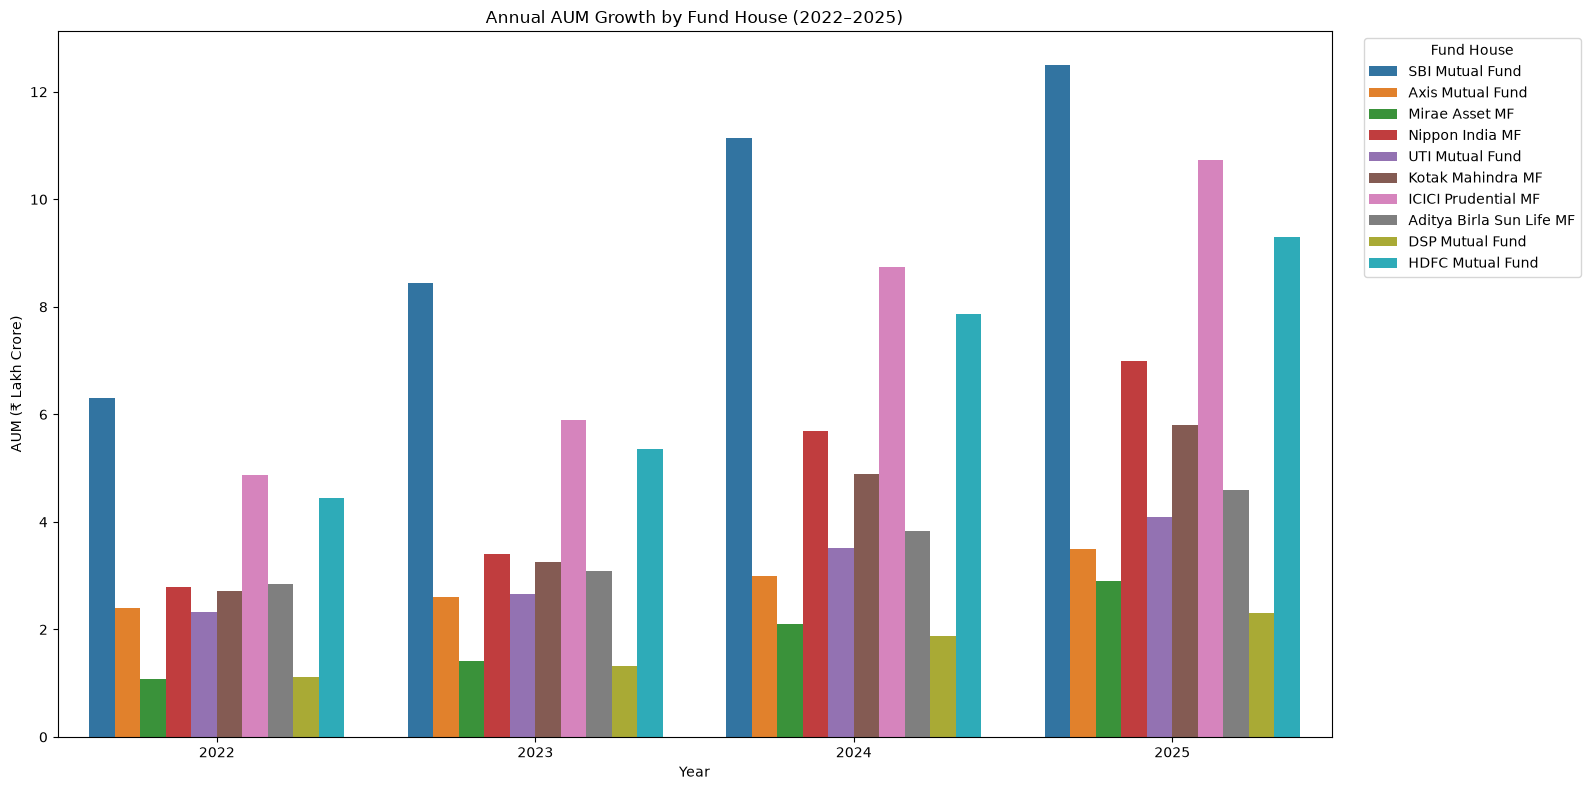

In [31]:
plt.figure(figsize=(16, 8))

sns.barplot(
    data=annual_aum,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)
plt.title("Annual AUM Growth by Fund House (2022–2025)")
plt.xlabel("Year")
plt.ylabel("AUM (₹ Lakh Crore)")
plt.xticks(rotation=0)

plt.legend(
    title="Fund House",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "aum_growth_by_fund_house.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [32]:
sbi = annual_aum[
    annual_aum["fund_house"].str.contains("SBI", case=False, na=False)
]

sbi

,year,fund_house,aum_lakh_crore
0,2022,SBI Mutual Fund,6.30
13,2023,SBI Mutual Fund,8.45
28,2024,SBI Mutual Fund,11.14
38,2025,SBI Mutual Fund,12.50


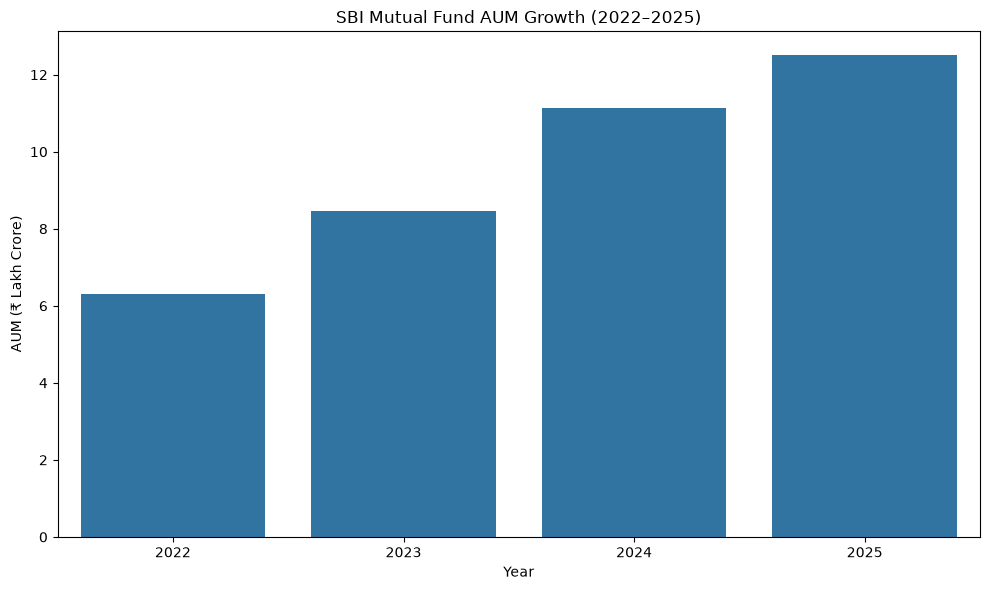

In [33]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=sbi,
    x="year",
    y="aum_lakh_crore"
)

plt.title("SBI Mutual Fund AUM Growth (2022–2025)")
plt.xlabel("Year")
plt.ylabel("AUM (₹ Lakh Crore)")

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "sbi_aum_dominance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [35]:
sip["month"] = pd.to_datetime(sip["month"])

sip = sip.sort_values("month")

sip.head()

,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01-01,11517,4.91,9.10,4.80,NaN
1,2022-02-01,11438,4.93,8.20,4.85,NaN
2,2022-03-01,12328,5.09,10.50,5.01,NaN
3,2022-04-01,11863,5.48,9.52,5.12,NaN
4,2022-05-01,12286,5.55,8.10,5.15,NaN


In [18]:
fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Inflows (2022–2026)",
    labels={
        "month": "Month",
        "sip_inflow_crore": "SIP Inflow (₹ Crore)"
    }
)

fig.update_layout(
    template="plotly_white",
    height=600
)

fig.show()

# Save only PNG
fig.write_image(
    OUTPUT_DIR / "monthly_sip_inflows.png",
    width=1400,
    height=600
)

print("SIP inflow PNG saved successfully!")

SIP inflow PNG saved successfully!


In [37]:
dec_2025 = sip[
    (sip["month"].dt.year == 2025) &
    (sip["month"].dt.month == 12)
]

dec_2025

,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
47,2025-12-01,31002,9.35,9.8,15.9,17.17


In [22]:
fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Inflows (2022–2026)",
    labels={
        "month": "Month",
        "sip_inflow_crore": "SIP Inflow (₹ Crore)"
    }
)

# December 2025 peak
dec_2025 = sip[sip["month"].astype(str).str.contains("2025-12")]

fig.add_scatter(
    x=dec_2025["month"],
    y=dec_2025["sip_inflow_crore"],
    mode="markers+text",
    text=["Dec 2025 Peak: ₹31,002 Cr"],
    textposition="top center",
    marker=dict(size=12),
    name="Dec 2025 Peak"
)

fig.update_layout(
    template="plotly_white",
    height=600
)

fig.show()

# Save only PNG
fig.write_image(
    OUTPUT_DIR / "sip_inflow_trend_highlighted.png",
    width=1400,
    height=600
)

print("SIP inflow highlighted PNG saved successfully!")

SIP inflow highlighted PNG saved successfully!


In [40]:
category_inflows.columns

Index(['month', 'category', 'net_inflow_crore'], dtype='str')

In [41]:
category_inflows["month"] = pd.to_datetime(category_inflows["month"])

category_inflows.head()

,month,category,net_inflow_crore
0,2024-04-01,Large Cap,2413.0
1,2024-04-01,Mid Cap,3897.0
2,2024-04-01,Small Cap,3533.0
3,2024-04-01,Flexi Cap,4947.0
4,2024-04-01,Large & Mid Cap,4214.0


In [42]:
category_inflows["month_name"] = category_inflows["month"].dt.strftime("%b")

month_order = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]

heatmap_data = category_inflows.pivot_table(
    index="category",
    columns="month_name",
    values="net_inflow_crore",
    aggfunc="sum"
)

heatmap_data = heatmap_data.reindex(columns=month_order)

heatmap_data

month_name,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
category,,,,,,,,,,,,
ELSS,516.0,437.0,500.0,466.0,553.0,472.0,471.0,499.0,537.0,537.0,571.0,521.0
Flexi Cap,5603.0,6068.0,4767.0,4947.0,5529.0,4478.0,4869.0,5562.0,5397.0,6004.0,6111.0,4654.0
Gilt,744.0,942.0,956.0,784.0,836.0,864.0,959.0,952.0,925.0,898.0,704.0,831.0
Hybrid,2967.0,3360.0,2830.0,2955.0,3487.0,3163.0,3291.0,3684.0,3015.0,3314.0,3264.0,3538.0
Large & Mid Cap,4816.0,5524.0,4243.0,4214.0,4368.0,4610.0,5023.0,5411.0,4528.0,4581.0,5556.0,4878.0
Large Cap,2025.0,1925.0,2234.0,2413.0,2076.0,2519.0,2574.0,1940.0,1879.0,2255.0,1870.0,1923.0
Liquid,33892.0,32374.0,38681.0,37537.0,41872.0,40486.0,34643.0,41952.0,35308.0,39091.0,40506.0,34933.0
Mid Cap,4316.0,4819.0,5061.0,3897.0,5300.0,5047.0,4548.0,3899.0,4960.0,4106.0,4336.0,5023.0
Sectoral/Thematic,7893.0,9215.0,8614.0,8052.0,8354.0,10030.0,9896.0,8360.0,8518.0,7680.0,7397.0,9820.0


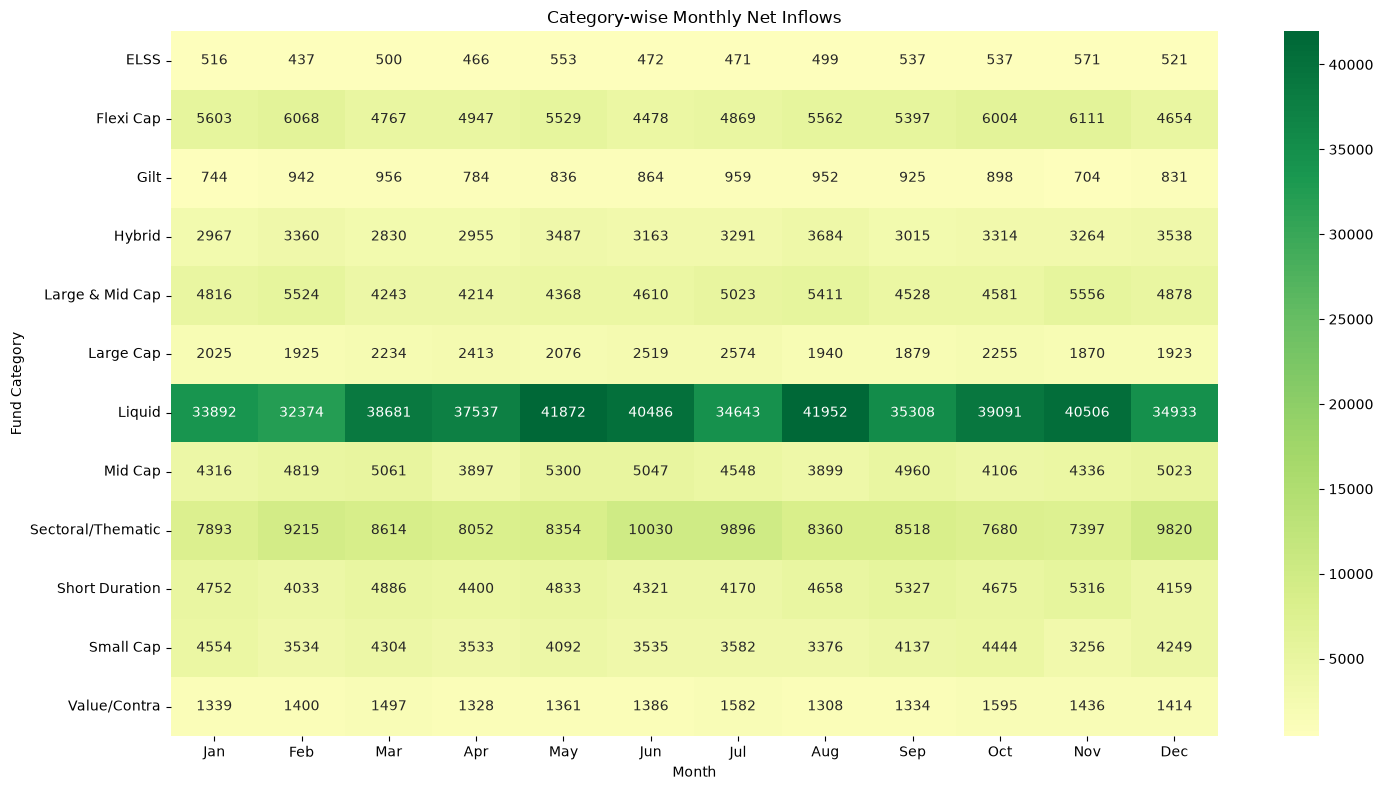

In [43]:
plt.figure(figsize=(15, 8))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".0f",
    cmap="RdYlGn",
    center=0
)

plt.title("Category-wise Monthly Net Inflows")
plt.xlabel("Month")
plt.ylabel("Fund Category")

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "category_inflow_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [44]:
transactions.columns

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='str')

In [45]:
transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


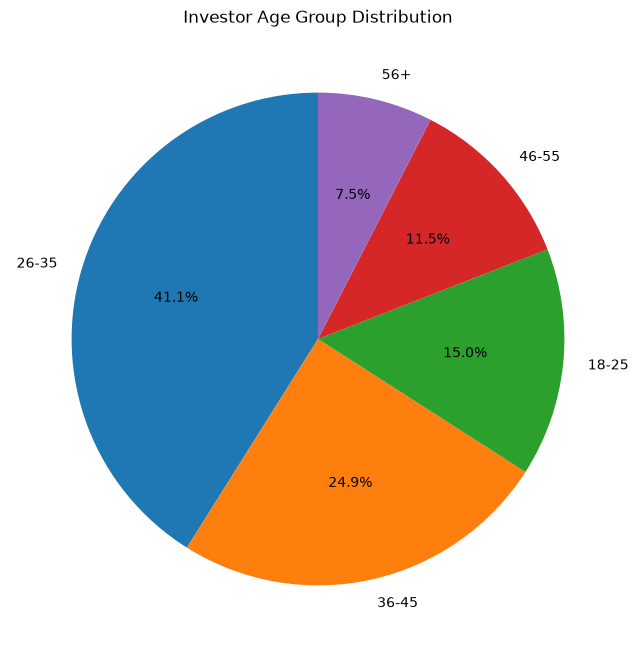

In [46]:
age_counts = transactions["age_group"].value_counts()

plt.figure(figsize=(8, 8))

plt.pie(
    age_counts.values,
    labels=age_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Investor Age Group Distribution")

plt.savefig(
    OUTPUT_DIR / "investor_age_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

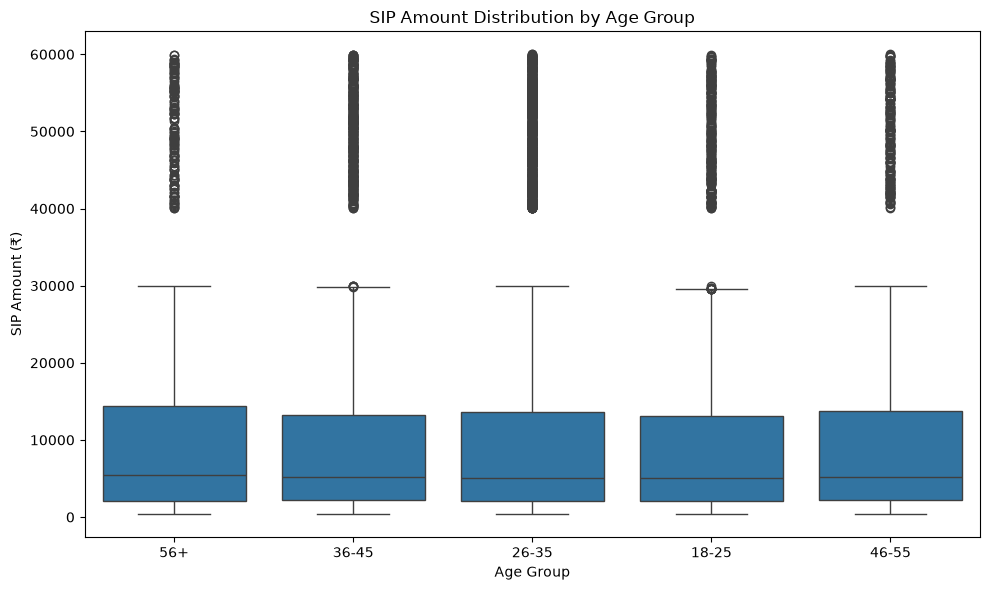

In [47]:
sip_transactions = transactions[
    transactions["transaction_type"] == "SIP"
].copy()

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=sip_transactions,
    x="age_group",
    y="amount_inr"
)

plt.title("SIP Amount Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("SIP Amount (₹)")

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "sip_amount_by_age.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

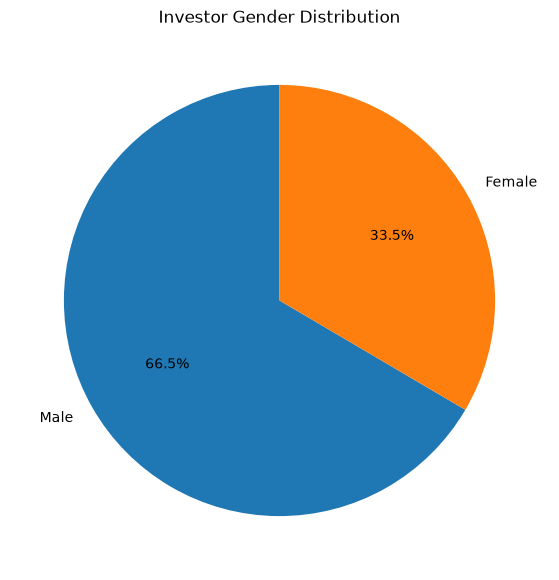

In [48]:
gender_counts = transactions["gender"].value_counts()

plt.figure(figsize=(7, 7))

plt.pie(
    gender_counts.values,
    labels=gender_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Investor Gender Distribution")

plt.savefig(
    OUTPUT_DIR / "gender_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

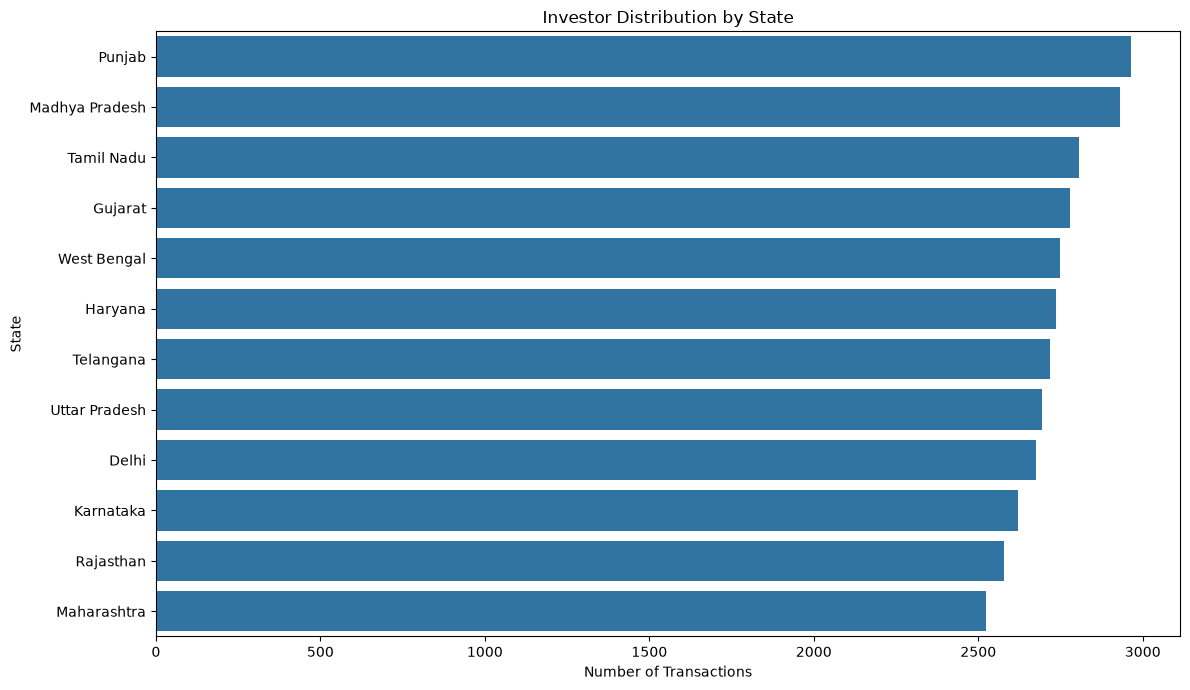

In [49]:
state_counts = transactions["state"].value_counts()

plt.figure(figsize=(12, 7))

sns.barplot(
    x=state_counts.values,
    y=state_counts.index
)

plt.title("Investor Distribution by State")
plt.xlabel("Number of Transactions")
plt.ylabel("State")

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "investor_distribution_by_state.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

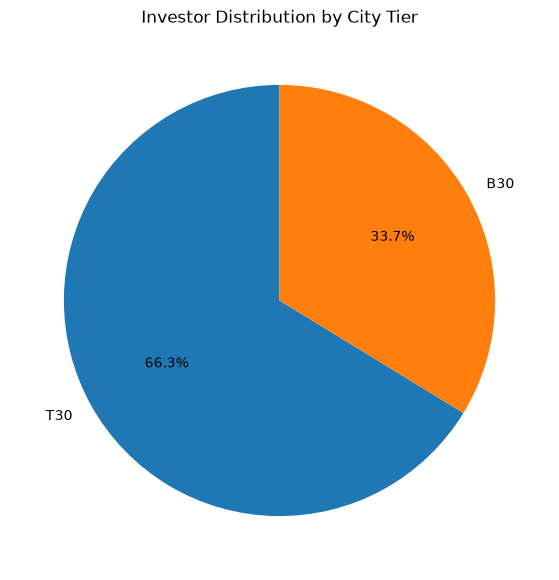

In [50]:
city_tier_counts = transactions["city_tier"].value_counts()

plt.figure(figsize=(7, 7))

plt.pie(
    city_tier_counts.values,
    labels=city_tier_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Investor Distribution by City Tier")

plt.savefig(
    OUTPUT_DIR / "investor_city_tier_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

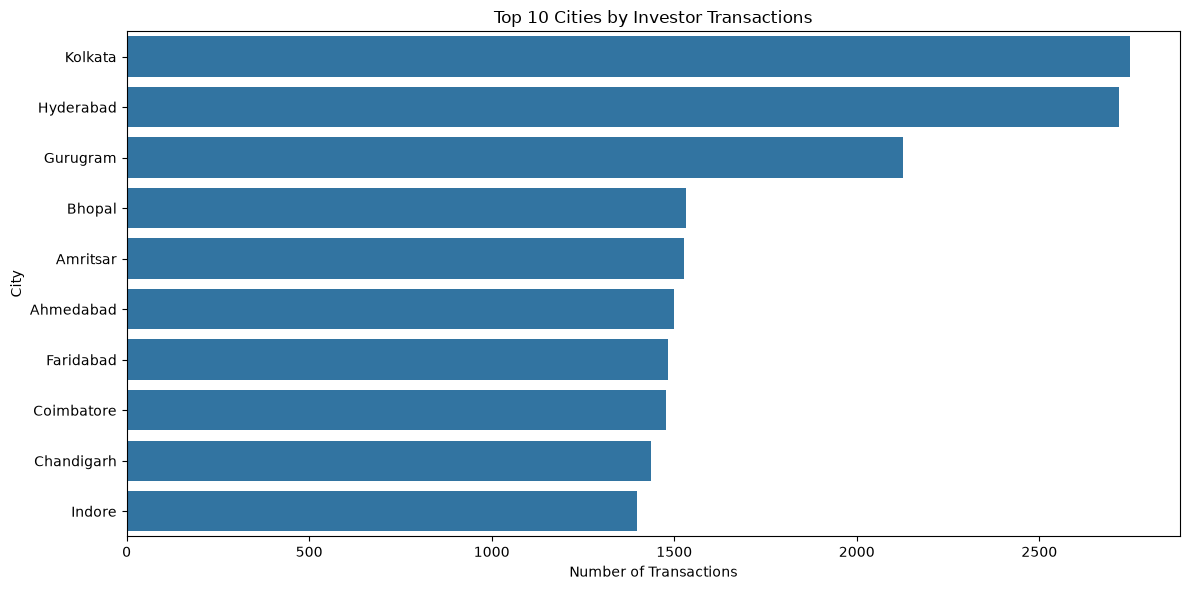

In [51]:
city_counts = transactions["city"].value_counts().head(10)

plt.figure(figsize=(12, 6))

sns.barplot(
    x=city_counts.values,
    y=city_counts.index
)

plt.title("Top 10 Cities by Investor Transactions")
plt.xlabel("Number of Transactions")
plt.ylabel("City")

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "top_10_investor_cities.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [52]:
folio.columns

Index(['month', 'total_folios_crore', 'equity_folios_crore',
       'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore'],
      dtype='str')

In [53]:
folio["month"] = pd.to_datetime(folio["month"])
folio = folio.sort_values("month")

folio.head()

,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
0,2022-01-01,13.26,9.28,1.86,0.80,1.33
1,2022-04-01,13.91,9.74,1.95,0.83,1.39
2,2022-07-01,13.85,9.69,1.94,0.83,1.38
3,2022-10-01,14.12,9.88,1.98,0.85,1.41
4,2023-01-01,14.81,10.37,2.07,0.89,1.48


In [23]:
fig = px.line(
    folio,
    x="month",
    y="total_folios_crore",
    title="Mutual Fund Folio Count Growth — 2022–2025",
    labels={
        "month": "Month",
        "total_folios_crore": "Total Folios (Crore)"
    },
    markers=True
)

fig.update_layout(
    template="plotly_white",
    height=600
)

fig.show()

# Save only PNG
fig.write_image(
    OUTPUT_DIR / "folio_count_growth.png",
    width=1400,
    height=600
)

print("Folio count growth PNG saved successfully!")

Folio count growth PNG saved successfully!


In [56]:
milestones = [15, 20, 25]

for milestone in milestones:
    crossed = folio[folio["total_folios_crore"] >= milestone]

    if not crossed.empty:
        print(
            f"{milestone} Cr crossed on",
            crossed.iloc[0]["month"].strftime("%Y-%m-%d")
        )
    else:
        print(f"{milestone} Cr was not reached in the dataset.")

15 Cr crossed on 2023-04-01
20 Cr crossed on 2024-10-01
25 Cr crossed on 2025-09-01


In [57]:
nav = nav.sort_values(["amfi_code", "date"])

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
    .pct_change()
)

nav[["amfi_code", "date", "nav", "daily_return"]].head(10)

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210
5755,100016,2022-01-10,510.7136,-0.008639
5756,100016,2022-01-11,513.5542,0.005562
5757,100016,2022-01-12,512.3195,-0.002404
5758,100016,2022-01-13,510.2445,-0.004050
5759,100016,2022-01-14,514.3636,0.008073


In [58]:
selected_funds = (
    nav["amfi_code"]
    .drop_duplicates()
    .head(10)
    .tolist()
)

selected_funds

[100016,
 100025,
 100033,
 101206,
 101207,
 101208,
 102885,
 102886,
 102887,
 118632]

In [59]:
return_data = nav[
    nav["amfi_code"].isin(selected_funds)
].pivot(
    index="date",
    columns="amfi_code",
    values="daily_return"
)

return_data.head()

amfi_code,100016,100025,100033,101206,101207,101208,102885,102886,102887,118632
date,,,,,,,,,,
2022-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-01-04,-0.010306,-0.003553,-0.013328,0.001153,-0.010865,-0.000141,0.011122,0.011314,-0.010459,-0.000714
2022-01-05,0.012865,-0.000050,-0.004386,0.003866,0.000603,0.000382,-0.007878,0.006779,-0.005308,0.005913
2022-01-06,-0.011377,-0.001880,-0.005167,-0.002128,-0.029101,-0.000143,0.015277,0.031127,0.012678,0.003540
2022-01-07,-0.001210,0.002036,-0.005748,-0.006314,0.024766,0.000215,-0.009369,-0.008835,-0.016498,-0.005793


In [60]:
correlation_matrix = return_data.corr()

correlation_matrix

amfi_code,100016,100025,100033,101206,101207,101208,102885,102886,102887,118632
amfi_code,,,,,,,,,,
100016,1.000000,0.045567,-0.000006,0.027747,0.016053,-0.033773,-0.093533,-0.005867,-0.023316,-0.026781
100025,0.045567,1.000000,0.002150,0.023769,-0.006710,0.018455,-0.001038,0.013754,-0.005648,-0.014166
100033,-0.000006,0.002150,1.000000,-0.018079,0.000351,0.007864,-0.034228,-0.018166,-0.036647,-0.013318
101206,0.027747,0.023769,-0.018079,1.000000,0.010202,-0.027230,0.001570,0.007229,-0.006490,-0.005432
101207,0.016053,-0.006710,0.000351,0.010202,1.000000,-0.007530,-0.005929,0.004860,0.002304,0.043384
101208,-0.033773,0.018455,0.007864,-0.027230,-0.007530,1.000000,-0.001436,0.014307,0.036547,0.003507
102885,-0.093533,-0.001038,-0.034228,0.001570,-0.005929,-0.001436,1.000000,0.020691,-0.036704,-0.000285
102886,-0.005867,0.013754,-0.018166,0.007229,0.004860,0.014307,0.020691,1.000000,-0.007865,-0.039886
102887,-0.023316,-0.005648,-0.036647,-0.006490,0.002304,0.036547,-0.036704,-0.007865,1.000000,0.001248


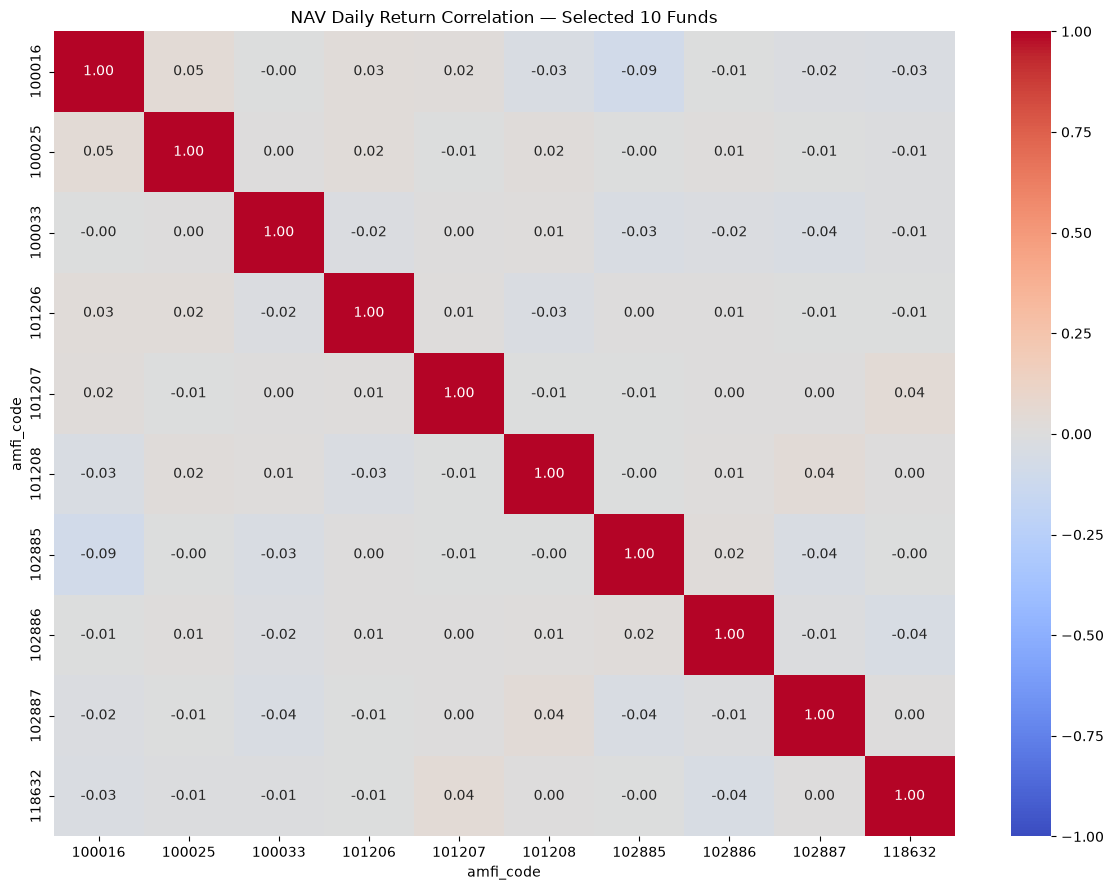

NAV return correlation heatmap saved successfully!


In [61]:
plt.figure(figsize=(12, 9))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1
)

plt.title("NAV Daily Return Correlation — Selected 10 Funds")

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "nav_return_correlation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("NAV return correlation heatmap saved successfully!")

In [62]:
holdings.columns

Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='str')

In [63]:
holdings.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [64]:
# Calculate total portfolio weight for each fund
fund_total_weight = (
    holdings
    .groupby("amfi_code")["weight_pct"]
    .sum()
    .reset_index(name="total_weight")
)

# Merge total fund weights back
holdings_normalized = holdings.merge(
    fund_total_weight,
    on="amfi_code",
    how="left"
)

# Normalize sector weights within each fund
holdings_normalized["normalized_weight"] = (
    holdings_normalized["weight_pct"] /
    holdings_normalized["total_weight"] * 100
)

# Aggregate sector allocation across funds
sector_allocation = (
    holdings_normalized
    .groupby("sector")["normalized_weight"]
    .mean()
    .sort_values(ascending=False)
)

sector_allocation

sector
Consumer Goods    14.179576
Diversified       12.087845
IT                11.387280
Utilities         11.064159
FMCG              10.909911
Banking           10.870983
NBFC              10.826266
Pharma            10.721945
Automobile         9.807551
Telecom            9.708045
Energy             9.070347
Paints             8.986332
Cement             8.752555
Infrastructure     8.734303
Name: normalized_weight, dtype: float64

In [65]:
# Normalize sector allocation to total 100%
sector_allocation = (
    sector_allocation /
    sector_allocation.sum() * 100
)

sector_allocation

sector
Consumer Goods    9.638948
Diversified       8.217037
IT                7.740809
Utilities         7.521159
FMCG              7.416305
Banking           7.389843
NBFC              7.359445
Pharma            7.288530
Automobile        6.666946
Telecom           6.599304
Energy            6.165812
Paints            6.108700
Cement            5.949784
Infrastructure    5.937377
Name: normalized_weight, dtype: float64

In [66]:
pip install -U "kaleido>=1"


   ---------------------------------------- 0/5 [simplejson]
   ---------------------------------------- 0/5 [simplejson]
   ---------------------------------------- 0/5 [simplejson]
   ---------------------------------------- 0/5 [simplejson]
   ---------------------------------------- 0/5 [simplejson]
   ---------------------------------------- 0/5 [simplejson]
   ---------------------------------------- 0/5 [simplejson]
   ---------------------------------------- 0/5 [simplejson]
   ---------------------------------------- 0/5 [simplejson]
   ---------------------------------------- 0/5 [simplejson]
   ---------------------------------------- 0/5 [simplejson]
   -------- ------------------------------- 1/5 [orjson]
   -------- ------------------------------- 1/5 [orjson]
   -------- ------------------------------- 1/5 [orjson]
   ------------------------ --------------- 3/5 [choreographer]
   ------------------------ --------------- 3/5 [choreographer]
   ------------------------ -


[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [85]:
pip install kaleido

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [66]:
import sys
print(sys.executable)

c:\Users\anjli\Downloads\mutual-fund-analytics\venv\Scripts\python.exe


In [67]:
import importlib.metadata

print(importlib.metadata.version("kaleido"))

1.1.0


In [26]:
# Check holdings data
print(holdings.head())
print(holdings.columns)

   amfi_code stock_symbol                stock_name       sector  weight_pct  \
0     119551    POWERGRID    Power Grid Corporation    Utilities       13.85   
1     119551     HDFCBANK             HDFC Bank Ltd      Banking       11.19   
2     119551       GRASIM     Grasim Industries Ltd  Diversified        9.90   
3     119551      DRREDDY  Dr. Reddy's Laboratories       Pharma        4.76   
4     119551   ASIANPAINT          Asian Paints Ltd       Paints       10.25   

   market_value_cr  current_price_inr portfolio_date  
0           737.09            6011.08     2025-12-31  
1            88.97            1074.65     2025-12-31  
2           208.45            5964.59     2025-12-31  
3           161.32            3748.82     2025-12-31  
4           725.90            1321.45     2025-12-31  
Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='str')


In [27]:
# Calculate aggregate sector allocation
sector_allocation = (
    holdings
    .groupby("sector")["weight_pct"]
    .sum()
)

# Normalize weights so they total 100%
sector_allocation = (
    sector_allocation / sector_allocation.sum() * 100
)

print(sector_allocation)
print("\nTotal:", sector_allocation.sum())

sector
Automobile         9.519146
Banking           19.184174
Cement             3.089127
Consumer Goods     3.753246
Diversified        4.977368
Energy             3.467951
FMCG               6.738549
IT                13.396216
Infrastructure     5.651781
NBFC               3.502657
Paints             2.642949
Pharma            11.983859
Telecom            4.282954
Utilities          7.810023
Name: weight_pct, dtype: float64

Total: 100.00000000000001


In [28]:
import plotly.express as px

fig = px.pie(
    sector_allocation.reset_index(),
    names="sector",
    values="weight_pct",
    hole=0.5,
    title="Aggregate Sector Allocation Across Equity Funds"
)

fig.update_traces(
    textinfo="percent",
    hovertemplate="<b>%{label}</b><br>Weight: %{value:.2f}%<extra></extra>"
)

fig.update_layout(
    template="plotly_white",
    height=700
)

fig.show()

# Save only PNG
fig.write_image(
    OUTPUT_DIR / "sector_allocation_donut.png",
    width=1400,
    height=700
)

print("Sector allocation donut PNG saved successfully!")

Sector allocation donut PNG saved successfully!
